In [1]:
from anomaly_detection.utils.scoring import QuantileScorer
import numpy as np
import matplotlib.pyplot as plt
import torch

In [7]:
from anomaly_detection.utils.load_sam_data import load_dataset
from anomaly_detection.utils.preprocess import minmax_scale_per_sample
full_dataset = load_dataset("FJ")
full_dataset = minmax_scale_per_sample(full_dataset)

Loading data from: C:\Users\hrdyj\coding\vyzkumak\data\FJ\FI01X1\FI01X1_ch


<BarContainer object of 96 artists>

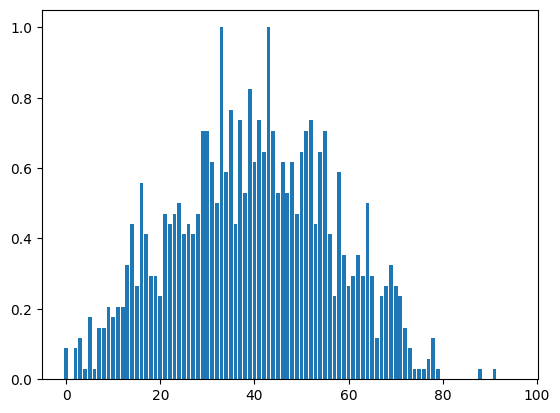

In [9]:
plt.bar(range(96), full_dataset[46])

<BarContainer object of 96 artists>

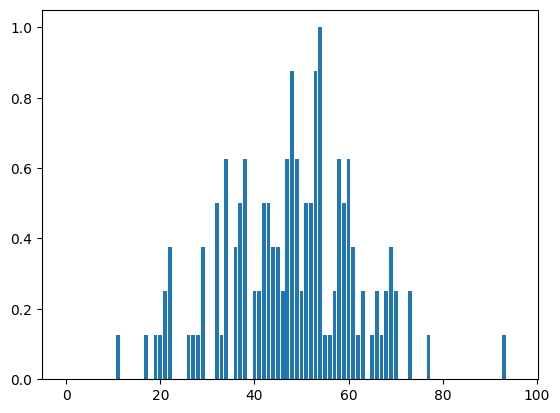

In [10]:
plt.bar(range(96), full_dataset[244])

mean: 0.66176474
i: 91.2


C:\Users\hrdyj\AppData\Local\Temp\ipykernel_29840\2703134577.py:1: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  residual = np.abs(full_dataset[244] - full_dataset[46])


<BarContainer object of 96 artists>

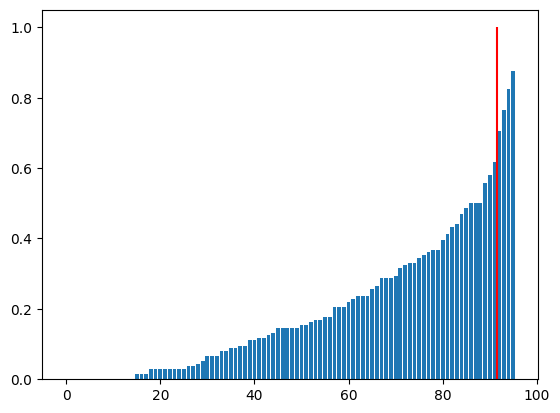

In [36]:
residual = np.abs(full_dataset[244] - full_dataset[46])
residual = sorted(residual)
q = 0.96
i = q * (96-1)

i_up = np.ceil(i)
i_down = np.floor(i)
print('mean:', np.mean((residual[int(i_up)], residual[int(i_down)])))

print("i:", i)
plt.vlines(np.mean((i_up, i_down)), ymin=0, ymax=1, zorder=2, color='red')
plt.bar(range(96), residual, zorder=0)

In [35]:
scorer = QuantileScorer(q=q)
scorer.score(full_dataset[244], full_dataset[46])

tensor(0.1471)

In [40]:
from anomaly_detection.config.paths import CHECKPOINT_DIR
from anomaly_detection.models.conv_ae_v3_1 import AE_v3
import os

checkpoint = torch.load(os.path.join(CHECKPOINT_DIR, "AE_conv_v3.1_Wass_Reg_train_date=01-03_10-20", "ae_conv_v3.1_Wass_Reg_ep246.pth"), map_location="cpu")

config = checkpoint["config"]

model = AE_v3()
model.load_state_dict(checkpoint["model_state_dict"])

model.eval()

AE_v3(
  (encoder): Sequential(
    (0): Conv1d(1, 2, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): BatchNorm1d(2, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv1d(2, 4, kernel_size=(3,), stride=(2,), padding=(1,))
    (4): BatchNorm1d(4, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): Conv1d(4, 8, kernel_size=(3,), stride=(1,), padding=(1,))
    (7): BatchNorm1d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU()
    (9): Conv1d(8, 16, kernel_size=(3,), stride=(2,), padding=(1,))
    (10): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): ReLU()
    (12): Conv1d(16, 32, kernel_size=(3,), stride=(1,), padding=(1,))
    (13): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (14): Sigmoid()
  )
  (decoder): Sequential(
    (0): ConvTranspose1d(32, 16, kernel_size=(3,), stride=(1,), padding

c:\Users\hrdyj\coding\vyzkumak\mlenv\Lib\site-packages\torch\nn\modules\loss.py:616: UserWarning: Using a target size (torch.Size([96])) that is different to the input size (torch.Size([1, 1, 96])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


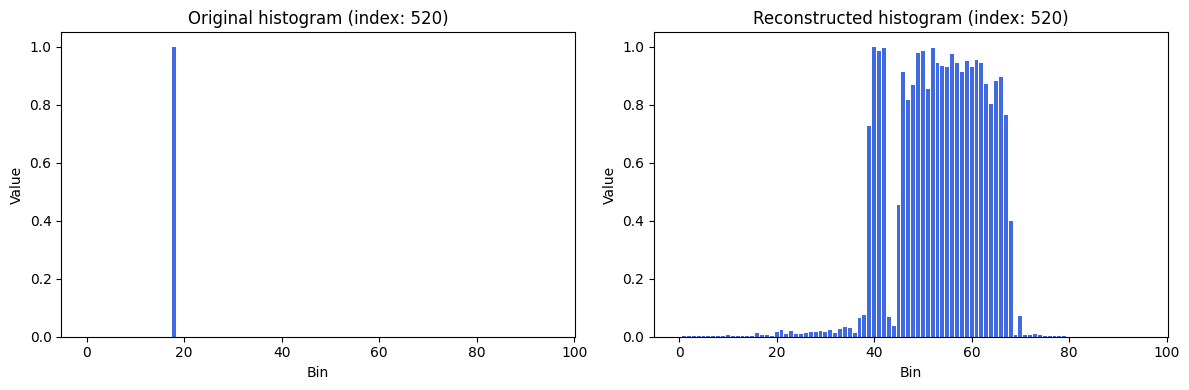

In [41]:
import torch.nn as nn
device = 'cpu'
model.eval()
idx = 520

with torch.no_grad():
    x = full_dataset[idx].to(device)
    pred = model(x.reshape(1,1,96))

    criterion = nn.MSELoss()
    loss = criterion(pred, x).item()

original = x.squeeze().cpu().numpy()
reconstructed = pred.squeeze().cpu().numpy()

_, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(range(len(original)), original, zorder=1, color='royalblue')
axes[0].set_title(f"Original histogram (index: {idx})")
axes[0].set_xlabel("Bin")
axes[0].set_ylabel("Value")

axes[1].bar(range(len(reconstructed)), reconstructed, zorder=1, color='royalblue')
axes[1].set_title(f"Reconstructed histogram (index: {idx})")
axes[1].set_xlabel("Bin")
axes[1].set_ylabel("Value")

plt.tight_layout()
plt.show()

Zoradené rezíduá: [[[1.3347615e-07 6.4069320e-07 8.6390054e-07 1.0407419e-06 1.3650276e-06
   1.5290690e-06 1.7760644e-06 2.8691036e-06 6.5858908e-06 9.1926831e-06
   9.5009000e-06 1.8534382e-05 2.0164334e-05 6.6298380e-05 1.0645942e-04
   1.8232054e-04 3.8753470e-04 1.1452585e-03 1.2420458e-03 1.2511457e-03
   1.2774190e-03 1.4577507e-03 1.5371463e-03 1.7704893e-03 1.7713001e-03
   1.8164988e-03 2.0960274e-03 2.3254724e-03 2.4146389e-03 2.6942499e-03
   3.1176128e-03 3.2654109e-03 3.4874026e-03 3.5682686e-03 3.9037128e-03
   3.9981529e-03 4.1505834e-03 4.4091041e-03 4.5988401e-03 5.3149043e-03
   6.3575134e-03 7.3902779e-03 7.4218502e-03 8.7692346e-03 9.7466195e-03
   1.0761395e-02 1.0891894e-02 1.2010174e-02 1.2237747e-02 1.2337495e-02
   1.3603414e-02 1.5041429e-02 1.5071383e-02 1.5336670e-02 1.7949097e-02
   1.8484771e-02 1.8521203e-02 2.1810414e-02 2.4421623e-02 2.4971941e-02
   2.8613009e-02 3.2328077e-02 3.6390230e-02 6.5200895e-02 6.6906229e-02
   7.0552997e-02 7.5998910e-02 3.

C:\Users\hrdyj\AppData\Local\Temp\ipykernel_29840\870376542.py:6: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  residual_raw = np.abs(x - pred)


TypeError: only length-1 arrays can be converted to Python scalars

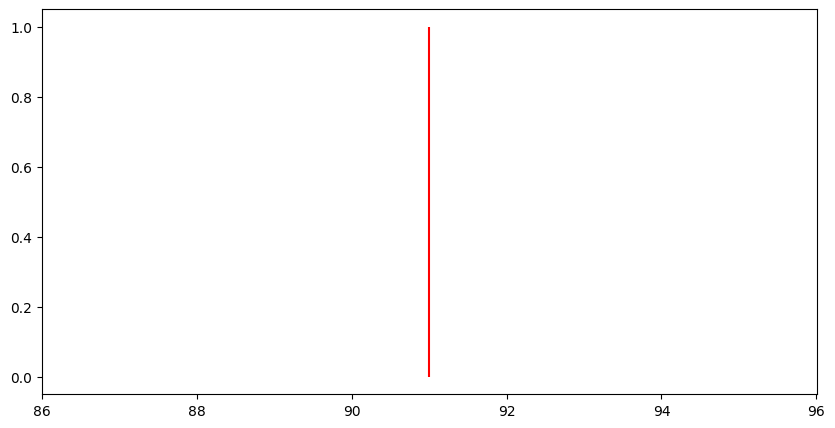

In [ ]:
# ukazat ako je ina krivka pri outliery a pri normalnom pointe bude zaujimave do prace !!!!!!!